# Exam 2025

In [449]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from jax import random
import seaborn as snb
from scipy.stats import beta as beta_dist
from scipy.stats import binom as binom_dist
from scipy.stats import betabinom as beta_binom_dist

## Part 1

### 1.1

In [450]:
def design_matrix(x):
    return jnp.column_stack((x**0, x**1, x**2, x**3))

x = jnp.array([0, 1, 2, 4, 5])
y = jnp.array([1, 0.5, -0.1, -0.9, 1.1])

The distribution will be $N(y \vert w^T \phi (x), \sigma^2)$, which can be written analytically in simplified log form $-0.5 log(2 \pi \sigma^2) - 0.5 (y - w^T \phi (x))^2 / \sigma^2$

### 1.2

MLE is given by $(\phi^T \phi)^{-1} \phi^T y$

In [451]:
phi = design_matrix(x)

w_MLE = jnp.linalg.inv(phi.T @ phi) @ phi.T @ y
w_MLE

Array([ 0.95335275,  0.26645964, -0.69327766,  0.12892161], dtype=float32)

### 1.3

Analytical distribution for posterior has mean $m = \beta S \phi^T y$ and variance $S = (\alpha I + \beta \phi^T \phi)^{-1}$, where $\beta = 1 / (1/5)$ and $\alpha = 1/2$

In [452]:
beta = 1/(1/5)**2
alpha = 1/2

S = jnp.linalg.inv(alpha * jnp.eye(len(phi.T @ phi)) + beta * phi.T @ phi)
m = beta * S @ phi.T @ y

Calculated, our variance for posterior is:

In [453]:
S

Array([[ 0.03658529, -0.0440213 ,  0.01481683, -0.0014999 ],
       [-0.04402122,  0.13294305, -0.06430177,  0.00799774],
       [ 0.01481685, -0.06430175,  0.03584206, -0.00480553],
       [-0.00149989,  0.00799773, -0.00480553,  0.00066975]],      dtype=float32)

and mean

In [454]:
m

Array([ 0.9469964 ,  0.24692926, -0.6790402 ,  0.12686208], dtype=float32)

### 1.4

Posterior predictive is given by: $N(y^* | m^T \phi_{ * }, \phi_{ * }^T S \phi_{*} + \sigma^2)$

In [455]:
x_star = jnp.array([3])
sigma = 1/5
phi_star = design_matrix(x_star)
ppred_m = m.T @ phi_star[0]
ppred_S = phi_star[0].T @ S @ phi_star[0] + sigma**2

The posterior predictive mean is then:

In [456]:
ppred_m

Array(-0.99830115, dtype=float32)

And variance

In [457]:
ppred_S

Array(0.0739619, dtype=float32)

## Part 2

### 2.1

We read off the figure and get an expected value for $w_1$:

In [458]:
0.5*(0.12+0.09) + 0.6*(0.12+0.2+0.12) + 0.7*(0.23+0.12)

0.614

The variance / second moment is then given as:

In [459]:
((0.5 - 0.614)**2)*(0.12+0.09) + ((0.6 - 0.614)**2) * (0.12+0.2+0.12) + ((0.7 - 0.614)**2) * (0.23+0.12)

0.005403999999999997

### 2.2

In [483]:
npdf = lambda x, m, v: jnp.exp(-(x-m)**2/(2*v))/jnp.sqrt(2*jnp.pi*v)

pairs = {(0.5, 0.2): 0.12, (0.5, 0.3): 0.09, (0.6, 0.1): 0.12, (0.6, 0.2): 0.2, (0.6, 0.3): 0.12, (0.7, 0.1): 0.23, (0.7, 0.2): 0.12}
def f(x, w1, w2):
    return jnp.exp(w1 + w2 * x)

total = 0 

x_star = 4

for key in pairs:
    total += npdf(4, f(x_star, key[0], key[1]), 1/2) * pairs[key]

total

Array(0.29489627, dtype=float32, weak_type=True)

So, the mean is 0.29

Variance is then:

In [484]:
total = 0 
mu = 0.29489627
sigma2 = 1/2

x_star = 4

for key in pairs:
    total += ((npdf(4, f(x_star, key[0], key[1]), 1/2) - mu)**2) * pairs[key]

total + sigma2

Array(0.5429038, dtype=float32, weak_type=True)

## Part 3

### 3.1

We sum over $z_1$ and get:

$([N(y_1 \vert 0, 1)] 0.2 + [N(y_1 \vert \theta^T x_1 , \sigma^2) 0.8] N(\theta \vert 0, \alpha^{-1} I))$

### 3.2

$p(y_1, z_1) = p(y_1 \vert z_1) p(z_1) = [(1 - z_1) N(y_1 \vert 0, 1) + z_1 N(y_1 \vert 0, x^T x \alpha^{-1} + \sigma^2)] Ber(z_1 \vert \pi)$

### 3.3

In [490]:
m1, m2 = 1/4, 1/4
v1, v2 = 6/5, 6/5
H = 0.5 * jnp.log(2 * jnp.pi * jnp.e * v1) + 0.5 * jnp.log(2 * jnp.pi * jnp.e * v2)
print(f'Entropy of q: {H:3.2f}')

Entropy of q: 3.02


### 3.4

In [465]:
lower = m2 - 1.96 * jnp.sqrt(v2)
upper = m2 + 1.96 * jnp.sqrt(v2)

lower, upper

(Array(-1.8970726, dtype=float32, weak_type=True),
 Array(2.3970726, dtype=float32, weak_type=True))

### 3.5

In [466]:
m = jnp.array([[1/4],[1/4]])
v = jnp.array([[6/5,0], [0, 6/5]])

x_star = jnp.array([[-1],[3]])

sigma_2 = 1/10
new_m = m.T @ x_star
new_V = x_star.T @ v @ x_star + sigma_2

In [467]:
new_m, new_V

(Array([[0.5]], dtype=float32), Array([[12.1]], dtype=float32))

So, N(0.5, 12.1)

### 3.6

I expect the KL divergence to be lower with a full rank gaussian (for $q_2^*$), due to including the covariances between variables and not just the variance of each variable.

## Part 4:

### 4.1

The analytical prior distribution for $p(f^*)$ is $N(f^* \vert 0, 10)$ since $k_1 (x^*, x^*) = 5(1+1)=10$ 

### 4.2

In [494]:
from jax import random
import jax.numpy as jnp

sigmoid = lambda x: 1. / (1 + jnp.exp(-x))

key = random.PRNGKey(0)
num_samples = 10000

# k1(x*, x*) = 5 * (1 + exp(0)) = 10
var_f_star = 10.0

# sample f* from N(0, 10)
f_samples = random.normal(key, (num_samples,)) * jnp.sqrt(var_f_star)

# average 1 - sigmoid(f*) over samples
p_y_eq_0 = jnp.mean(1 - sigmoid(f_samples))
print(f'p(y*=0 | x*) ≈ {p_y_eq_0:.3f}')

p(y*=0 | x*) ≈ 0.500


### 4.3

In [471]:
m = jnp.array([[1.56],[0.84], [-0.32]])
S = jnp.array([[2.69, 1.46, 0.42], [1.46, 1.78, 1.2], [0.42, 1.2, 2.13]])

In [472]:
class StationaryIsotropicKernel(object):

    def __init__(self, kernel_fun):
        """
            the argument kernel_fun must be a function of two arguments kernel_fun(||tau||, hyperparameters), e.g. 
            squared_exponential = lambda tau, hyper: hyper.kappa**2*np.exp(-0.5*tau**2/hyper.lengthscale**2).
        """
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix or None
            hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]

        ##############################################
        # Your solution goes here
        ##############################################
        
        # compute all the pairwise distances efficiently (can also be done using nested for loops)
        dists = jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1)
        
        # squared exponential covariance function
        K = self.kernel_fun(dists, hyperparameters)
        
        # add jitter to diagonal for numerical stability
        if len(X1) == len(X2) and jnp.allclose(X1, X2):
            K = K + jitter*jnp.identity(len(X1))
        
        ##############################################
        # End of solution
        ##############################################
        
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K

In [473]:
from dataclasses import dataclass
@dataclass
class Hyperparameters(object):

    def to_array(self):
        """ return hyperparameters as flat JaX-array (to be used later) """
        return jnp.array([])
        
    @staticmethod
    def from_array(hyper_array):
        """ instantiates Hyperparameter object from flat JaX-array (or list) of hyperparameters (to be used later) """
        kappa, lengthscale, sigma = hyper_array
        return Hyperparameters()
    
    def __repr__(self):
        """ for reporting hyperparameter values """
        return f''
    
def generate_samples(key, m, K, num_samples, jitter=0):
    """ returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.

    
    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)
    
    returns 
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))

    ##############################################
    # Your solution goes here
    ##############################################
    
    N = len(K)
    L = jnp.linalg.cholesky(K + jitter*jnp.identity(N))
    f_samples = m[:, None] + jnp.dot(L, zs)
    
    ##############################################
    # End of solution
    ##############################################

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    return f_samples


class BernoulliLikelihood(object):
    """ Implement the Bernoulli likelihood with the sigmoid as inverse link function """

    def __init__(self, y):
        # store data & force shape (N, )
        self.y = y.ravel()

    def log_lik(self, f):
        """ Implements log p(y|f) = sum log p(y_n|f_n), where p(y_n|f_n) = Ber(y_n|sigmoid(f_n)). 
            
            Argument:
            f       --       vector of function values, shape (N, )

            Returns
            ll      --       sum of log likelihoods for all N data points, scalar

        """
        ##############################################
        # Your solution goes here
        ##############################################
        
        p = sigmoid(f)
        ll = jnp.sum(self.y*jnp.log(p) + (1-self.y)*jnp.log(1-p))
        
        ##############################################
        # End of solution
        ##############################################

        # check shape and return
        assert ll.shape == (), f"Expected shape for loglik_ is (), but the actual shape was {ll.shape}. Please check implementation"
        return ll
    
    def grad(self, f):
        """ Implements the gradient of log p(y|n) 

            Argument:
            f       --       vector of function values, shape (N, )

            Returns
            g       --       gradient of log p(y|f), i.e. a vector of first order derivatives with shape (N, )
             
        """
        ##############################################
        # Your solution goes here
        ##############################################
        
        g = self.y - sigmoid(f)
        
        ##############################################
        # End of solution
        ##############################################
        # check shape and return
        assert g.shape == (len(f), ), f"Expected shape for g is ({len(f)}, ), but the actual shape was {g.shape}. Please check implementation"
        return g

    def hessian(self, f):
        """ Implements the Hessian of log p(y|n) 

        Argument:
            f       --       vector of function values, shape (N, )

        Returns:
            Lambda  --       Hessian of likelihood, i.e. a diagonal matrix with the second order derivatives on the diagonal, shape (N, N)
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        p = sigmoid(f)
        Lambda = jnp.diag(-p*(1-p))    
        
        ##############################################
        # End of solution
        ##############################################

        # check shape and return
        assert Lambda.shape == (len(f), len(f)), f"Expected shape for Lambda is ({len(f)}, {len(f)}), but the actual shape was {Lambda.shape}. Please check implementation"
        return Lambda

In [474]:
from scipy.stats import norm

probit = lambda x: norm.cdf(x)

class GaussianProcessClassification(object):

    def __init__(self, X, y, likelihood, kernel, hyperparameters, jitter=1e-8):
        """  
        Arguments:
            X                -- NxD input points
            y                -- Nx1 observed values 
            likelihood       -- likelihood instance
            kernel           -- must be instance of the StationaryIsotropicKernel class
            jitter           -- non-negative scaler
            hyperparameters  -- Hyperparameter object containing kernel hyperparameters and noise std. dev. 
        """
        self.X = X
        self.y = y
        self.N = len(X)
        self.likelihood = likelihood(y)
        self.kernel = kernel
        self.jitter = jitter
        self.hyperparameters = hyperparameters
        self.check_dimensions()

        # prepare Laplace approx
        self.precompute_kernel_matrices()
        self.m = m
        self.S = S
        #self.construct_laplace_approximation()

    def check_dimensions(self):
        assert self.X.ndim == 2, f"The variable X must be of shape (N, D), however, the current shape is: {self.X.shape}"
        N, D = self.X.shape

        assert self.y.ndim == 2, f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"
        assert self.y.shape == (N, 1), f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"

    def precompute_kernel_matrices(self):
        """ precomputes kernel matrix and its Cholesky decomposition """
        self.K = self.kernel.construct_kernel(self.X, self.X, self.hyperparameters, self.jitter)
        self.L = jnp.linalg.cholesky(self.K)

    # def set_hyperparameters(self, hyper):
    #     self.hyperparameters = hyper
    #     # recompute with new hyperparameters
    #     self.precompute_kernel_matrices()
    #     self.construct_laplace_approximation()
        


    def predict_f(self, Xstar):
        """ returns the posterior distribution of f^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- mean vector, shape (P,)
        Sigma            -- covariance matrix, shape (P, P) 
        """
        ##############################################
        # Your solution goes here
        ##############################################
        
        k = self.kernel.construct_kernel(Xstar, self.X, self.hyperparameters, self.jitter)
        Kp = self.kernel.construct_kernel(Xstar, Xstar, self.hyperparameters, self.jitter)

        h = jnp.linalg.solve(self.K, k.T)
        mu = k@jnp.linalg.solve(self.K, self.m)
        Sigma = Kp - h.T@(self.K-self.S)@h
        
        ##############################################
        # End of solution
        ##############################################

        # check dimensions and return
        #assert (mu.shape == (len(Xstar),)), f"Expected shape for mu is ({len(Xstar)}), but the actual shape was {mu.shape}. Please check implementation"
        #assert Sigma.shape == (len(Xstar), len(Xstar)), f"Expected shape for Sigma is ({len(Xstar)}, {len(Xstar)}), but the actual shape was {Sigma.shape}. Please check implementation"

        return mu, Sigma
    
    def predict_y(self, Xstar):
        """ returns the posterior distribution of y^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        p               -- vector of post. pred. probabilities, shape (P,)
        """
        ##############################################
        # Your solution goes here
        ##############################################
        
        mu, Sigma = self.predict_f(Xstar)
        p = probit(mu/jnp.sqrt(8/jnp.pi + jnp.diag(Sigma)))
        
        ##############################################
        # End of solution
        ##############################################

        # check dimensions and return
        #assert (p.shape == (len(Xstar),)), f"Expected shape for p is ({len(Xstar)}), but the actual shape was {p.shape}. Please check implementation"
        return p
    
    def posterior_samples(self, Xstar, num_samples):
        """
            generate samples from the posterior p(f^*|y, x^*) for each of the inputs in Xstar

            Arguments:
                Xstar            -- PxD prediction points
        
            returns:
                f_samples        -- numpy array of (P, num_samples) containing num_samples for each of the P inputs in Xstar
        """
        mu, Sigma = self.predict_f(Xstar)
        f_samples = generate_samples(mu.ravel(), Sigma, num_samples)

        assert (f_samples.shape == (len(Xstar), num_samples)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, {num_samples}), but actual shape was {f_samples.shape}. Please check implementation"
        return f_samples

# prep kernel, likelihood and Gaussian process

def squared_exponential(tau, hyperparameters):
    return 5*(1 + jnp.exp(-(1/4) * tau))

X = jnp.array([1, 2, 3])
X = X[:, None]
y = jnp.array([1, 1, 0])
y = y[:, None]

hyper = Hyperparameters()
kernel = StationaryIsotropicKernel(squared_exponential)
likelihood = BernoulliLikelihood
gpc = GaussianProcessClassification(X, y, likelihood, kernel, hyper)

x_star = jnp.array([4])

gpc.predict_f(x_star)

(Array([[-0.70821816]], dtype=float32), Array([[4.1643176]], dtype=float32))

So the distribution is $\mathcal{N}(-0.71, 4.16)$

### 4.4

In [475]:
gpc.predict_y(x_star)

array([[0.39227734]])

### 4.5

A prior variance of 0.5 instead of 5, so areas with less data will have smaller 95%-intervals.

## Part 5

In [476]:
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v)

### 5.1

In [477]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        ##############################################
        # Your solution goes here
        ##############################################
        

        # get the last value for theta and generate new proposal candidate
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
        
        # evaluate the log density for the candidate sample
        log_p_theta_star = log_target(theta_star)

        # compute acceptance probability
        log_r = log_p_theta_star - log_p_theta
        A = min(1, jnp.exp(log_r))
        
        # accept new candidate with probability A
        if random.uniform(key_accept) < A:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)


        
        ##############################################
        # End of solution
        ##############################################
            
        thetas.append(theta_next)


        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Acceptance ratio: 0.46


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Acceptance ratio: 0.47


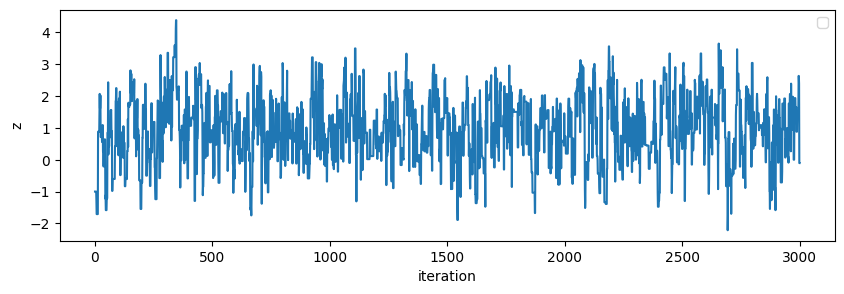

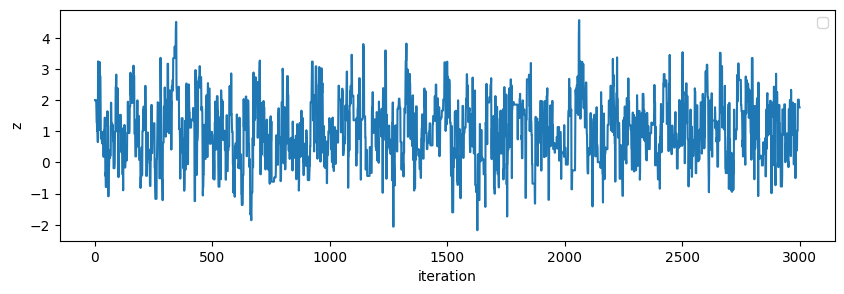

In [478]:
def log_post_dens(theta):
    z, x = theta[0], theta[1]
    return log_npdf(x, 0, jnp.exp(z))+log_npdf(z, 1, 1)

# specify number of parameters in the target distribution
num_params = 2
# specify the parameters of the MH algorithm
num_iterations = 3000
warm_up = int(1*num_iterations)
tau = jnp.sqrt(2)

# run sampler
thetas = metropolis(log_post_dens, num_params, tau, num_iterations, theta_init=jnp.array([-1, 0]))
x_line = jnp.linspace(1, num_iterations, num_iterations + 1)
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(x_line, thetas[:, 0])
ax.set(xlabel='iteration', ylabel='z')
ax.legend();

thetas = metropolis(log_post_dens, num_params, tau, num_iterations, theta_init=jnp.array([2, 5]))
x_line = jnp.linspace(1, num_iterations, num_iterations + 1)
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(x_line, thetas[:, 0])
ax.set(xlabel='iteration', ylabel='z')
ax.legend();

### 5.2

In [479]:
thetas1 = metropolis(log_post_dens, num_params, tau, num_iterations, theta_init=jnp.array([-1, 0]), seed=0)
thetas2 = metropolis(log_post_dens, num_params, tau, num_iterations, theta_init=jnp.array([2, 5]), seed=0)

Acceptance ratio: 0.46
Acceptance ratio: 0.47


In [480]:
samples = jnp.concatenate([thetas1, thetas2])

z_s = thetas[:, 0]
x_s = thetas[:, 1]

jnp.mean((samples[:, 0] - samples[:, 1])**2)

Array(4.2514014, dtype=float32)

### 5.3

In [481]:
jnp.mean(samples[:, 1] < 1)

Array(0.72509164, dtype=float32)